# Test PathFinder with simulated data

Generate random data with known rank and test Pathfinder's ability to reconstruct the data.


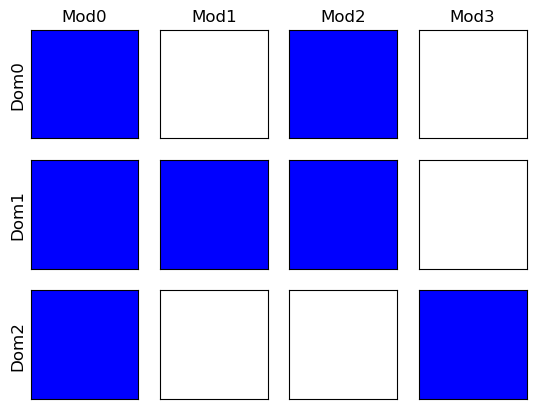

In [28]:
from pathfinder import decomp, utils

# -- here while dev in progress
import importlib
importlib.reload(utils)
importlib.reload(decomp)
# ---

# simulate data
data_dict, data_complete = utils.simulate_data_grid(num_domains=3, 
                                                    num_modalities=4, 
                                                    missing=[(0,1),(0,3),(1,3),(2,1),(2,2)],
                                                    output_complete=True)

# visualise data organisation
_ = utils.plot_data_grid(data_dict)


In [29]:

# Fit the data
from sklearn.linear_model import Ridge
algo = decomp.JointOuterDecomp(n_components=5, n_iter=30, dropout=-1,
                               method=Ridge, method_kwargs={'alpha':1e2}, do_ica='both')

algo.fit(data_dict)


100%|█████████████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 34.11it/s]


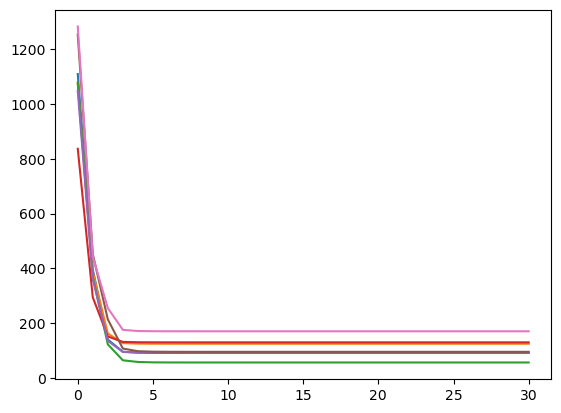

In [30]:
# Plot error
import matplotlib.pyplot as plt
_ = plt.plot(algo._loss)



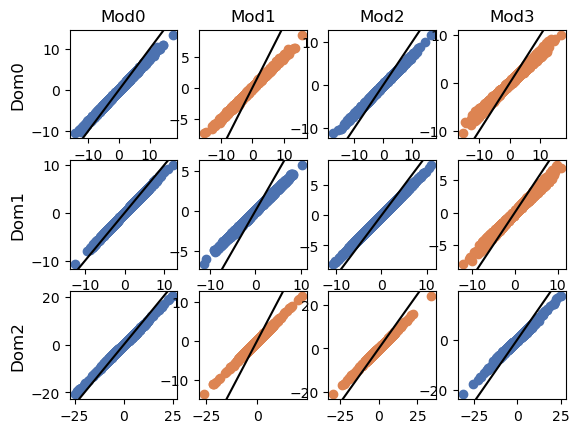

In [31]:
# Plot data and fit
_ = utils.plot_data_fit(data_dict, algo._A, algo._S, data_complete)
